<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

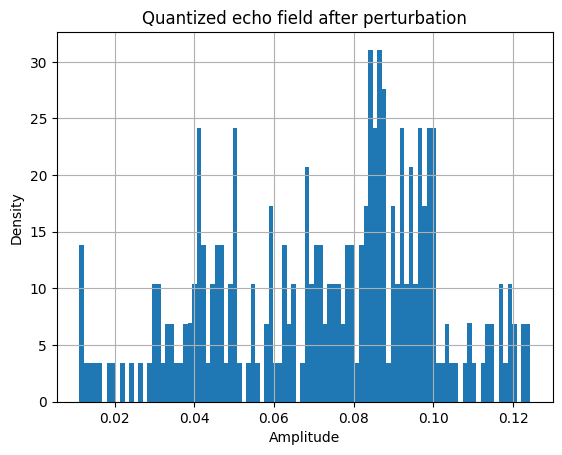

Post-perturbation quantized levels: [0.0411838  0.05023585 0.05928789 0.06833993 0.08418101 0.08644402
 0.09210155 0.09662757 0.09889059]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# -----------------------------
# Reinitialize quantized echo field from QFT025a
# -----------------------------
N_grid = 256
x = np.linspace(0, 2*np.pi, N_grid, endpoint=False)
A = 0.1
sigma = 0.2
N_nodes = 20
theta = np.pi / 3
centers = np.random.choice(x, size=N_nodes, replace=False)

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

nodes = [gaussian(c, sigma, A) * np.cos(theta) for c in centers]
phi = sum(nodes)

# -----------------------------
# Echo dynamics parameters
# -----------------------------
dt = 0.01
gamma = 0.005
lam = 0.1

def laplacian(phi):
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def evolve(phi):
    lap = laplacian(phi)
    nonlinear = lam * np.clip(phi, -1.0, 1.0)**3
    phi = phi + dt * (lap - gamma * phi + nonlinear)
    return np.clip(phi, -1.0, 1.0)

# -----------------------------
# Perturb and evolve
# -----------------------------
phi_perturbed = phi + 0.005 * np.random.normal(0, 1, size=len(phi))
history = [phi_perturbed.copy()]

for t in range(300):
    phi_perturbed = evolve(phi_perturbed)
    if t % 50 == 0:
        history.append(phi_perturbed.copy())

# -----------------------------
# Histogram and peak detection
# -----------------------------
plt.hist(phi_perturbed, bins=100, density=True)
plt.xlabel("Amplitude")
plt.ylabel("Density")
plt.title("Quantized echo field after perturbation")
plt.grid(True)
plt.show()

counts, bins = np.histogram(phi_perturbed, bins=100)
peaks, _ = find_peaks(counts, prominence=5)
peak_positions = 0.5 * (bins[peaks] + bins[peaks+1])
print("Post-perturbation quantized levels:", peak_positions)
